*NOTE*: notebook generated by Claude

# PR #664 spatial-disaggregation fix comparison — pr, global

Compares three global `CESM2-WACCM` / `pr` / `BCSD` runs (SSP245 ensemble member `003`, historical ensemble member `r3i1p1f1`) across **two different stores**:

| label | store | branch | what it is |
|---|---|---|---|
| `baseline` | production (`source.coop`) | `v0.13.0` | released production output *predating PR #664 entirely* — a different code version, not just a different disaggregation setting on the same debiasing run. Also predates the method-prefix namespacing, so its group paths have no `bcsd/` segment. |
| `simple_rolling` | qa scratch | `pr664-global-simple-rolling-mean-test001` | full pipeline run, `disaggregation_clim_method="simple_rolling"` |
| `tiny_thresh` | qa scratch | `pr664-global-tiny-thresh-standalone-pr-test001` | **disaggregation-only** — debiasing was not rerun; this branch's `debiased_coarse` was borrowed directly from `simple_rolling`'s (see `docs/how-to/pipeline-stage-debugger-disaggregation-only.ipynb`), and only the final downscaled arrays were written, using `clim_method="fft"`, `use_tiny_threshold=True` |

**Important asymmetry vs. the rsds version of this notebook** (`notebooks/QA_QC/rsds/pr664_global_rsds_comparison.ipynb`): there, all three branches shared the same recent debiasing code and only differed in disaggregation settings, so a `debiased_coarse` mismatch was a real bug signal. Here, `baseline` is a genuinely different code version, so a `debiased_coarse` difference between it and the others is *expected* and just reflects whatever changed since v0.13.0 — not evidence of a new problem. The only pair with debiasing held exactly fixed is `simple_rolling`/`tiny_thresh` (by construction), but `tiny_thresh` has no `debiased_coarse` of its own to compare against at all.

**Known gaps as of writing:** `tiny_thresh` only has the **historical** downscaled output (SSP245 hasn't been run) and has **no `debiased_coarse`** (by design). Both are detected by the availability check below, and every section skips what it can't do rather than failing.

**Dropped from the rsds version:** the zonal day-of-year-max check (`flag_rsds_above_max`) is rsds-specific — solar geometry gives a physically motivated latitude/day-of-year ceiling that precipitation has no equivalent of. The global plausible-range check does double duty as the primary implausible-value check here instead, and it's the one that would catch a `pr`-specific version of the negative-value bug found for rsds (pr's valid range starts at 0).

In [1]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm import catalog
from srm.config import _icechunk_storage_for_path
from srm.downscaling_utils import interpolate_coarse_to_fine_grid
from srm.qa_flags import (
    DIR_QA_FLAG_CONSTANT_INPUTS,
    SCENARIO_COMPARISONS,
    TREND_VARIABLE_SETTINGS,
    calculate_ensemble_mean_deltas,
    calculate_thresholds,
    flag_global_exceedances,
    flag_outliers,
    plot_flags,
)
from srm.qaqc import area_weights, calculate_distortion_flags, sign_flip_mask

In [2]:
# --- Run parameters --------------------------------------------------------
GCM = "CESM2-WACCM"
VAR = "pr"

QA_STORE = "s3://carbonplan-srm/scratch/snapshot/output/qa/CESM2-WACCM-ERA5-global.icechunk"
PROD_STORE = (
    "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling"
    "/output/production/CESM2-WACCM-ERA5-global.icechunk"
)

# "method" is the bcsd/qdmsd group-path prefix -- None means the store predates that
# namespacing and groups sit directly at the root (see leaf_path() below).
BRANCHES = {
    "baseline": {"store": PROD_STORE, "branch": "v0.13.0", "method": None},
    "simple_rolling": {
        "store": QA_STORE,
        "branch": "pr664-global-simple-rolling-mean-test001",
        "method": "bcsd",
    },
    "tiny_thresh": {
        "store": QA_STORE,
        "branch": "pr664-global-tiny-thresh-test003",
        "method": "bcsd",
    },
}

# Ensemble-member id format differs by scenario in this pipeline: historical leaves are
# keyed by CMIP6 variant id, SSP245 leaves by the pipeline's own zero-padded member number.
ENSEMBLE_BY_SCENARIO = {"historical": "r3i1p1f1", "ssp245": "003"}
SCENARIOS = ["historical", "ssp245"]

## Open each branch and discover what's actually there

In [3]:
# Optional but recommended for the full global x 3-branch x 2-scenario read below --
# see prior guidance to prefer a Coiled cluster over local reads for S3-backed data,
# even for small extractions. Skip this cell for a quick single-branch/point look.
#
# import coiled
# from frisky import hijack
#
# cluster = coiled.Cluster(
#     name="srm-pr664-pr-comparison",
#     region="us-west-2",
#     n_workers=8,
#     worker_vm_types=["m8gn.xlarge"],
#     scheduler_vm_types="c8g.xlarge",
#     spot_policy="spot_with_fallback",
#     use_best_zone=True,
#     tags={"Project": "SRM"},
#     worker_options={"nthreads": 8},
#     environ={"ZARR_ASYNC__CONCURRENCY": "128"},
# )
# client = hijack(cluster.get_client())
# client

In [4]:
_repo_cache: dict[str, icechunk.Repository] = {}


def _repo_for(store_path: str) -> icechunk.Repository:
    if store_path not in _repo_cache:
        _repo_cache[store_path] = icechunk.Repository.open(_icechunk_storage_for_path(store_path))
    return _repo_cache[store_path]


trees = {}
for label, cfg in BRANCHES.items():
    repo = _repo_for(cfg["store"])
    session = repo.readonly_session(branch=cfg["branch"])
    trees[label] = xr.open_datatree(session.store, engine="zarr", consolidated=False, chunks="auto")

In [5]:
SOURCES = ["downscaled", "debiased_coarse"]


def leaf_path(method: str | None, scenario: str, ens: str, debiased_coarse: bool = False) -> str:
    parts = []
    if method:
        parts.append(method)
    if debiased_coarse:
        parts.append("debiased_coarse")
    parts += [scenario, VAR, ens]
    return "/".join(parts)


def has_leaf(tree: xr.DataTree, path: str) -> bool:
    try:
        node = tree[path]
    except KeyError:
        return False
    return VAR in node.dataset.data_vars


availability = {
    label: {
        scenario: {
            source: has_leaf(
                trees[label],
                leaf_path(
                    cfg["method"],
                    scenario,
                    ENSEMBLE_BY_SCENARIO[scenario],
                    debiased_coarse=(source == "debiased_coarse"),
                ),
            )
            for source in SOURCES
        }
        for scenario in SCENARIOS
    }
    for label, cfg in BRANCHES.items()
}

In [6]:
pd.DataFrame(
    {
        (label, source): {scenario: availability[label][scenario][source] for scenario in SCENARIOS}
        for label in BRANCHES
        for source in SOURCES
    }
).T

historical  ssp245
baseline       downscaled             True    True
               debiased_coarse        True    True
simple_rolling downscaled             True    True
               debiased_coarse        True    True
tiny_thresh    downscaled             True    True
               debiased_coarse        True    True

In [7]:
# (label, scenario) -> DataArray, only for leaves that actually exist
data = {
    (label, scenario): trees[label][
        leaf_path(BRANCHES[label]["method"], scenario, ENSEMBLE_BY_SCENARIO[scenario])
    ].dataset[VAR]
    for label in BRANCHES
    for scenario in SCENARIOS
    if availability[label][scenario]["downscaled"]
}

# Same, but the pre-disaggregation debiased_coarse output on the native GCM grid.
data_coarse = {
    (label, scenario): trees[label][
        leaf_path(
            BRANCHES[label]["method"],
            scenario,
            ENSEMBLE_BY_SCENARIO[scenario],
            debiased_coarse=True,
        )
    ].dataset[VAR]
    for label in BRANCHES
    for scenario in SCENARIOS
    if availability[label][scenario]["debiased_coarse"]
}

sorted(data.keys()), sorted(data_coarse.keys())

([('baseline', 'historical'),
  ('baseline', 'ssp245'),
  ('simple_rolling', 'historical'),
  ('simple_rolling', 'ssp245'),
  ('tiny_thresh', 'historical'),
  ('tiny_thresh', 'ssp245')],
 [('baseline', 'historical'),
  ('baseline', 'ssp245'),
  ('simple_rolling', 'historical'),
  ('simple_rolling', 'ssp245'),
  ('tiny_thresh', 'historical'),
  ('tiny_thresh', 'ssp245')])

In [8]:
data_ref_hist = data[("baseline", "historical")].mean(dim="time").load()
data_ref_ssp245 = data[("baseline", "ssp245")].mean(dim="time").load()

baseline, historical
baseline, ssp245
simple_rolling, historical


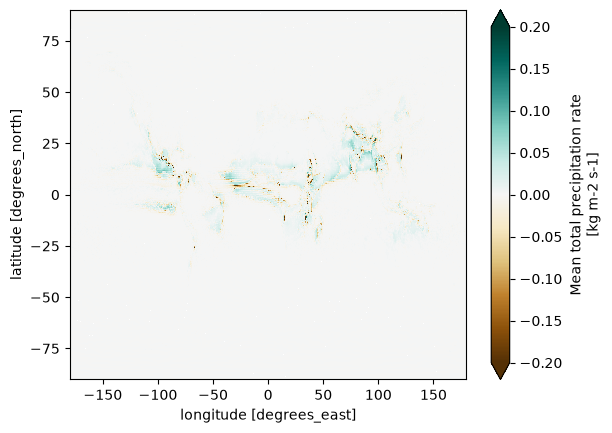

simple_rolling, ssp245


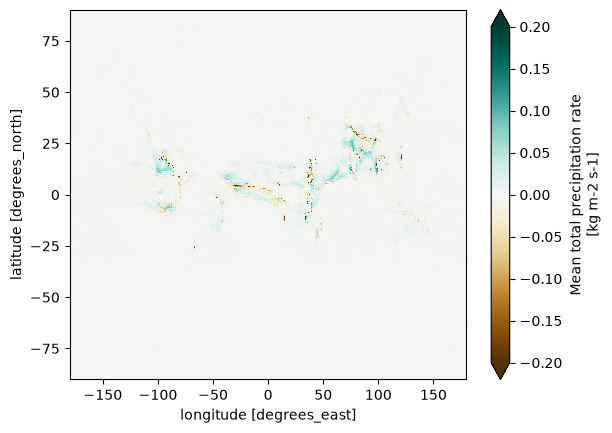

tiny_thresh, historical


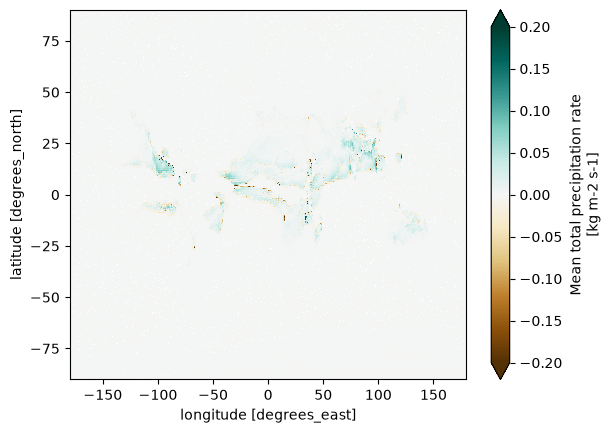

tiny_thresh, ssp245


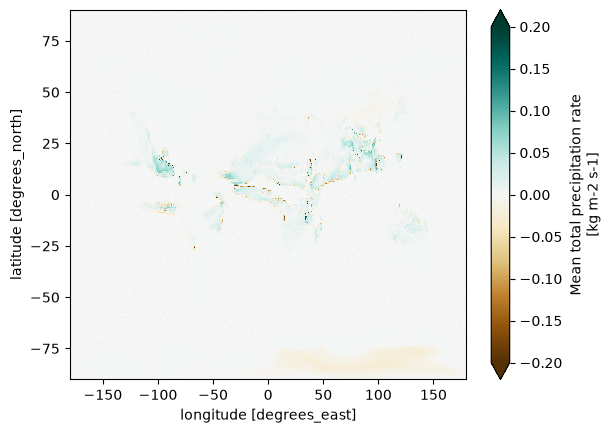

In [9]:
for (label, scenario), da in data.items():
    print(label + ", " + scenario)
    if label != "baseline":
        comp_mean = data[(label, scenario)].mean(dim="time")
        if scenario == "historical":
            delta = comp_mean - data_ref_hist
        elif scenario == "ssp245":
            delta = comp_mean - data_ref_ssp245
        (delta.where(np.abs(delta) > 0) * 86400).plot(cmap=plt.cm.BrBG, vmax=0.2, vmin=-0.2)
        plt.show()

## Sanity check: debiased_coarse comparison

**Read this differently than in the rsds notebook.** `tiny_thresh` has no `debiased_coarse` of its own (it borrowed `simple_rolling`'s directly, so by construction there's nothing to check between that pair). The only comparison possible here is `simple_rolling` vs. `baseline` — and since `baseline` is a different code version (not just a different disaggregation setting on the same debiasing run), a nonzero diff is *expected* and is information about what changed since v0.13.0, not a bug signal.

In [10]:
debiased_coarse_diffs = {}
for scenario in SCENARIOS:
    if ("baseline", scenario) not in data_coarse:
        print(f"skipping {scenario}: baseline debiased_coarse missing")
        continue
    baseline_da = data_coarse[("baseline", scenario)]
    for label in BRANCHES:
        if label == "baseline" or (label, scenario) not in data_coarse:
            continue
        diff = data_coarse[(label, scenario)] - baseline_da
        max_abs_diff = float(np.abs(diff).max().compute())
        debiased_coarse_diffs[(label, scenario)] = max_abs_diff
        identical = max_abs_diff == 0.0
        status = (
            "identical"
            if identical
            else "differs (expected vs. baseline -- different code version)"
        )
        print(f"{label} vs baseline / {scenario}: max abs diff = {max_abs_diff:.3e} ({status})")
        if not identical:
            diff.max(dim="time").plot()
            plt.title(f"{label} - baseline debiased_coarse, {scenario} (max over time)")
            plt.show()

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


simple_rolling vs baseline / historical: max abs diff = 0.000e+00 (identical)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


tiny_thresh vs baseline / historical: max abs diff = 0.000e+00 (identical)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


simple_rolling vs baseline / ssp245: max abs diff = 0.000e+00 (identical)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


tiny_thresh vs baseline / ssp245: max abs diff = 0.000e+00 (identical)


In [11]:
debiased_coarse_summary = pd.DataFrame(
    {
        f"{label}/{scenario}": {"max_abs_diff": diff}
        for (label, scenario), diff in debiased_coarse_diffs.items()
    }
).T
debiased_coarse_summary

,max_abs_diff
simple_rolling/historical,0.0
tiny_thresh/historical,0.0
simple_rolling/ssp245,0.0
tiny_thresh/ssp245,0.0


## Shared helpers: area-weighted flag summaries

`trend_distortion`/`flipped_sign` (Evaluation 3) are time-invariant already (2D, no `time` dim) — `summarize_flag` handles those directly. `outside_global_plausible_range` and `annual_outlier_flag` are time-varying, but nothing downstream ever needs a single day's value: the plots are always a time-aggregate map and the summary stats are always totals/fractions over all time. So each of those is reduced over `time` **once** right after it's computed, and both the plot and `summarize_flag_count` reuse that one small 2D count — instead of the full per-day array getting re-read from S3 and re-reduced separately for the plot and again for each summary stat.

In [12]:
def summarize_flag(flag: xr.DataArray) -> dict:
    """For time-invariant (already 2D) flags -- trend_distortion/flipped_sign."""
    weights = area_weights(flag["lat"])
    flagged = int(flag.sum().compute())
    pct_flagged = 100 * flagged / flag.size
    area_weighted_pct = 100 * float(flag.astype("float64").weighted(weights).mean().compute())
    return {
        "flagged_cells": flagged,
        "pct_flagged": pct_flagged,
        "area_weighted_pct": area_weighted_pct,
    }


def summarize_flag_count(count: xr.DataArray, n_time: int) -> dict:
    """For time-varying flags, given a per-pixel day count (flag.sum(dim='time'), already
    computed once) and the number of days it was summed over -- avoids re-touching the full
    per-day array a second time just to get summary stats.
    """
    weights = area_weights(count["lat"])
    flagged = int(count.sum().compute())
    pct_flagged = 100 * flagged / (count.size * n_time)
    frac_flagged = count / n_time
    area_weighted_pct = 100 * float(frac_flagged.weighted(weights).mean().compute())
    return {
        "flagged_pixel_days": flagged,
        "pct_flagged": pct_flagged,
        "area_weighted_pct": area_weighted_pct,
    }

## Evaluation 1: implausible pr values (global plausible range)

`flag_global_exceedances` against `VAR_SPATIAL_RANGES["pr"]` (min 0) — this is the primary implausible-value check for `pr`. Unlike the rsds notebook, there's no zonal day-of-year-max check here (that one relies on solar geometry giving a physically motivated latitude/day-of-year ceiling; precipitation has no equivalent). This check is what would catch a `pr` version of the negative-value bug found for rsds. Runs on both `data` (downscaled) and `data_coarse` (debiased_coarse) since it's a fixed numeric range with no grid dependency.

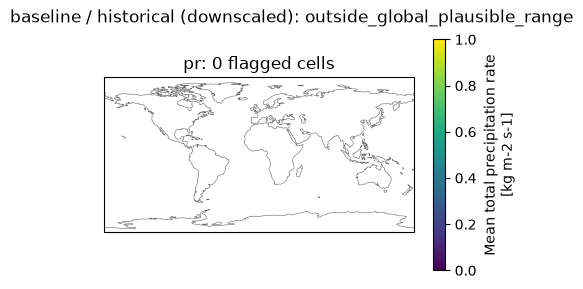

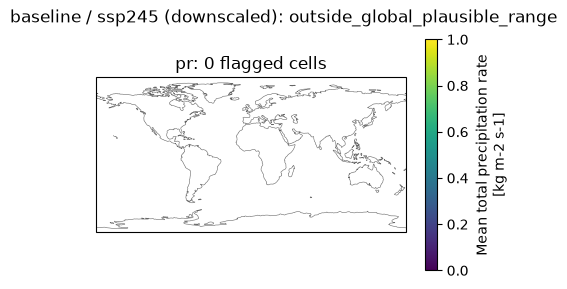

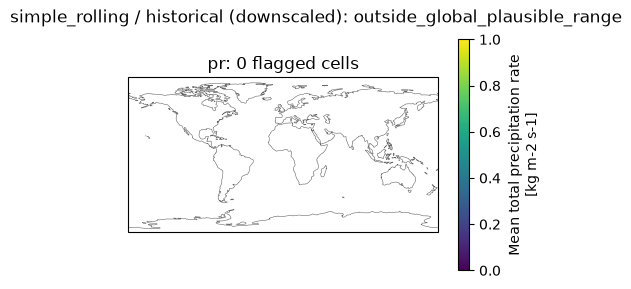

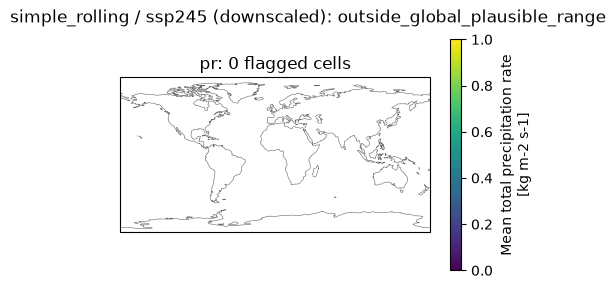

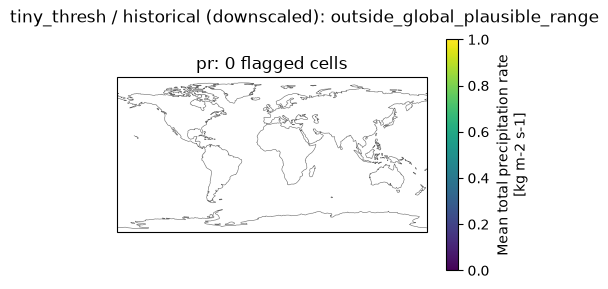

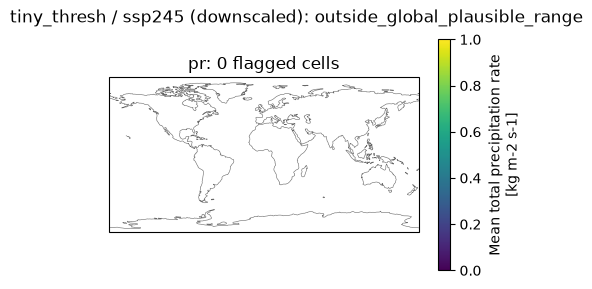

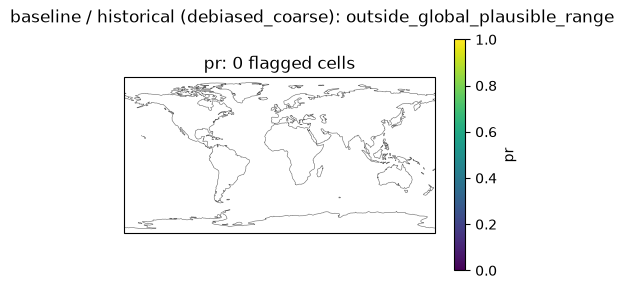

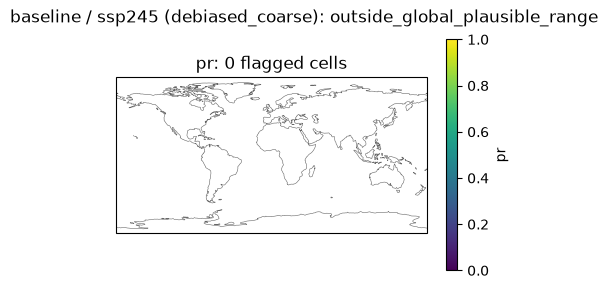

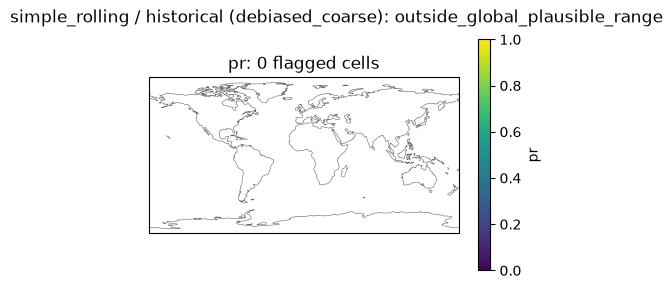

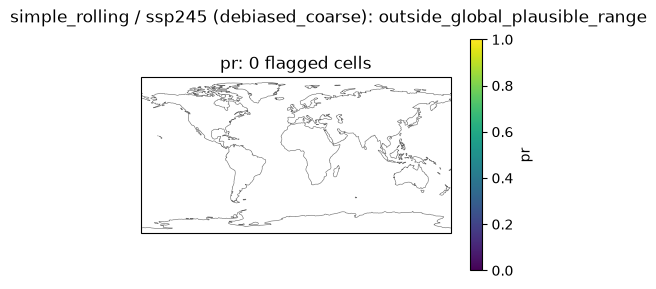

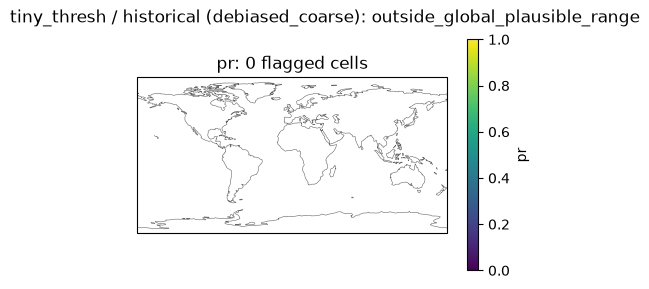

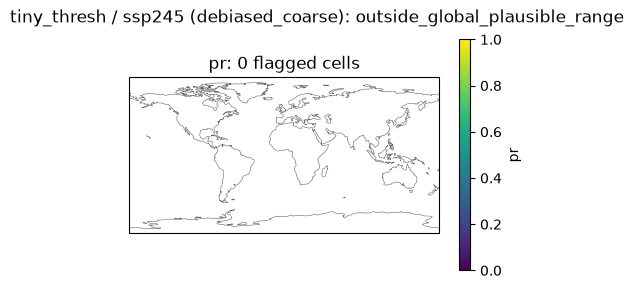

In [13]:
global_exceedance_flag = {}
for (label, scenario), da in data.items():
    flag = flag_global_exceedances(da=da, var=VAR)
    flag_count = flag.sum(dim="time").load()
    global_exceedance_flag[(label, scenario, "downscaled")] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label} / {scenario} (downscaled): outside_global_plausible_range")
    plt.show()

for (label, scenario), da in data_coarse.items():
    flag = flag_global_exceedances(da=da, var=VAR)
    flag_count = flag.sum(dim="time").load()
    global_exceedance_flag[(label, scenario, "debiased_coarse")] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label} / {scenario} (debiased_coarse): outside_global_plausible_range")
    plt.show()

In [14]:
def _n_time_for(label, scenario, source):
    return (data if source == "downscaled" else data_coarse)[(label, scenario)].sizes["time"]


global_exceedance_summary = pd.DataFrame(
    {
        f"{label}/{scenario}/{source}": summarize_flag_count(
            count, n_time=_n_time_for(label, scenario, source)
        )
        for (label, scenario, source), count in global_exceedance_flag.items()
    }
).T
global_exceedance_summary

,flagged_pixel_days,pct_flagged,area_weighted_pct
baseline/historical/downscaled,0.0,0.0,0.0
baseline/ssp245/downscaled,0.0,0.0,0.0
simple_rolling/historical/downscaled,0.0,0.0,0.0
simple_rolling/ssp245/downscaled,0.0,0.0,0.0
tiny_thresh/historical/downscaled,0.0,0.0,0.0
tiny_thresh/ssp245/downscaled,0.0,0.0,0.0
baseline/historical/debiased_coarse,0.0,0.0,0.0
baseline/ssp245/debiased_coarse,0.0,0.0,0.0
simple_rolling/historical/debiased_coarse,0.0,0.0,0.0
simple_rolling/ssp245/debiased_coarse,0.0,0.0,0.0


## Evaluation 2: annual outliers vs the ERA5 observational record

`flag_outliers` against the cached day-of-year ERA5 thresholds, collapsed to a single annual bound the same way production's `annual_outlier_flag` does. ERA5-fine-grid-only, so `data` (downscaled) only, not `data_coarse`.

In [15]:
combined = xr.open_zarr(DIR_QA_FLAG_CONSTANT_INPUTS + "doy_obs_thresholds_global.zarr")


def _split(ds, suffix):
    names = [v for v in ds.data_vars if v.endswith(suffix)]
    return ds[names].rename({v: v[: -len(suffix)] for v in names})


obs_max = _split(combined, "_max")
obs_min = _split(combined, "_min")
obs_max_std = _split(combined, "_max_std")
obs_min_std = _split(combined, "_min_std")

outlier_thresh_low, outlier_thresh_high = calculate_thresholds(
    obs_max, obs_min, obs_max_std, obs_min_std
)
outlier_thresh_low_annual = outlier_thresh_low.min(dim="dayofyear")[VAR]
outlier_thresh_high_annual = outlier_thresh_high.max(dim="dayofyear")[VAR]

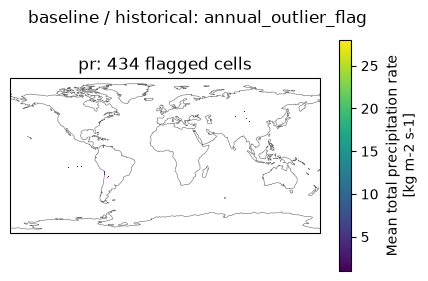

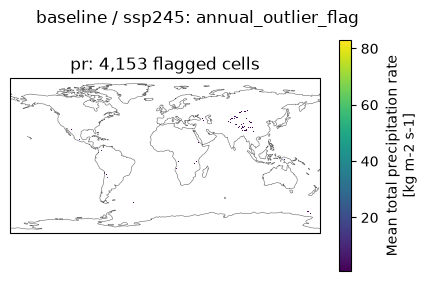

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


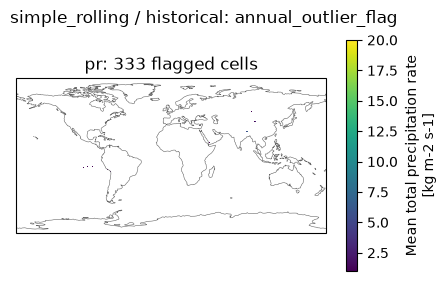

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(


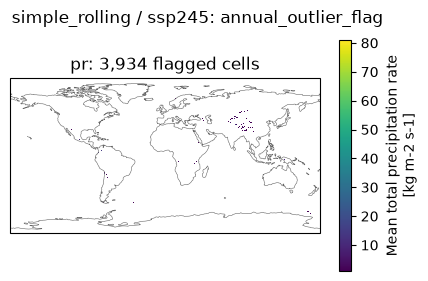

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


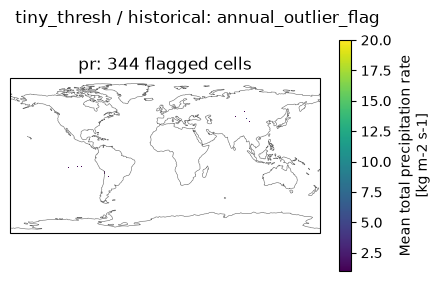

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(


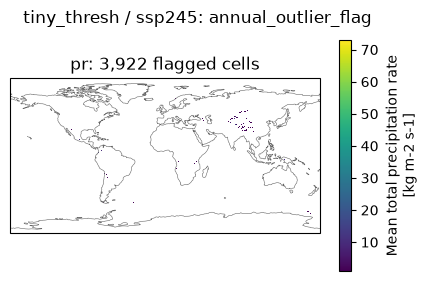

In [16]:
annual_outlier_flag = {}
for (label, scenario), da in data.items():
    flag = flag_outliers(
        da=da,
        outlier_thresh_low=outlier_thresh_low_annual,
        outlier_thresh_high=outlier_thresh_high_annual,
        timescale="annual",
    )
    flag_count = flag.sum(dim="time").load()
    annual_outlier_flag[(label, scenario)] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label} / {scenario}: annual_outlier_flag")
    plt.show()

In [17]:
annual_outlier_summary = pd.DataFrame(
    {
        f"{label}/{scenario}": summarize_flag_count(
            count, n_time=data[(label, scenario)].sizes["time"]
        )
        for (label, scenario), count in annual_outlier_flag.items()
    }
).T
annual_outlier_summary

,flagged_pixel_days,pct_flagged,area_weighted_pct
baseline/historical,434.0,0.000003,0.000004
baseline/ssp245,4153.0,0.000013,0.000017
simple_rolling/historical,333.0,0.000002,0.000003
simple_rolling/ssp245,3934.0,0.000012,0.000016
tiny_thresh/historical,344.0,0.000002,0.000003
tiny_thresh/ssp245,3922.0,0.000012,0.000016


## Evaluation 3: trend distortion, historical → SSP245 (single ensemble member)

Same production distortion chain as the rsds notebook (`calculate_ensemble_mean_deltas` + `calculate_distortion_flags` + `sign_flip_mask`, `SCENARIO_COMPARISONS["ssp245_hist"]`, `TREND_VARIABLE_SETTINGS["pr"]`). Tag construction is method-aware here: `baseline` has no method segment, so its tag uses `qa_flags`'s `"no-method-specified"` convention (already built into `get_data`/`parse_tag`) instead of `"bcsd"`.

Only run for branches where both `historical` and `ssp245` pr leaves exist — `tiny_thresh` is skipped until its `ssp245` leaf lands.

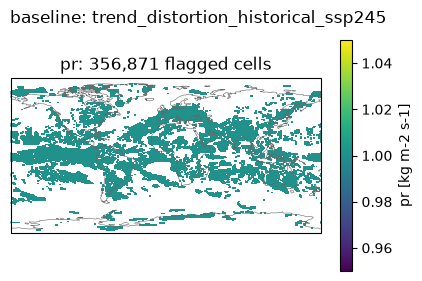

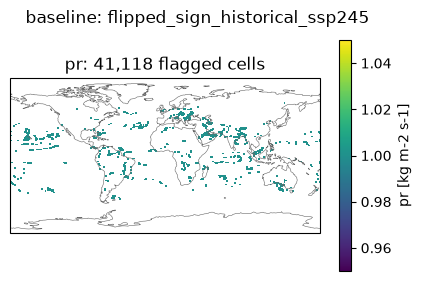

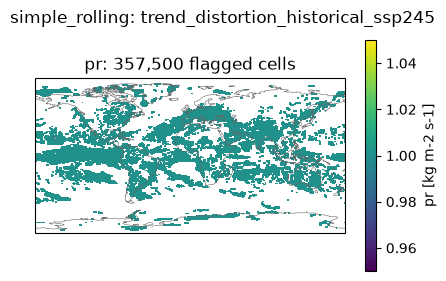

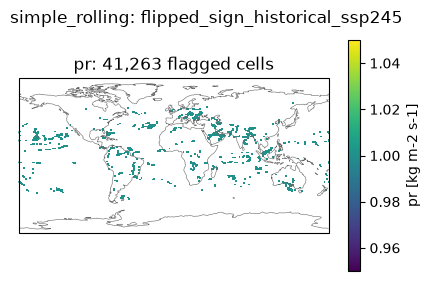

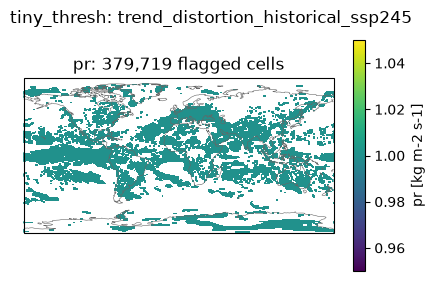

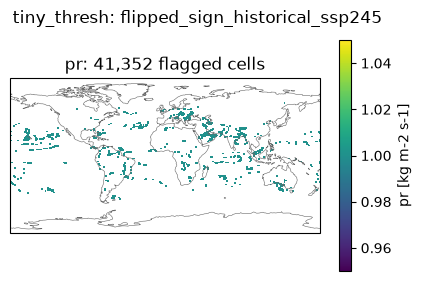

In [18]:
comparison = SCENARIO_COMPARISONS["ssp245_hist"]
settings = TREND_VARIABLE_SETTINGS[VAR]

trend_distortion_flag_fine = {}
flipped_sign_flag_fine = {}

for label, cfg in BRANCHES.items():
    if not (
        availability[label]["historical"]["downscaled"]
        and availability[label]["ssp245"]["downscaled"]
    ):
        print(f"skipping {label}: missing historical and/or ssp245 pr output")
        continue

    method_tag = cfg["method"] or "no-method-specified"
    tag_hist = f"{GCM}_{VAR}_historical_{ENSEMBLE_BY_SCENARIO['historical']}_{method_tag}"
    tag_ssp = f"{GCM}_{VAR}_ssp245_{ENSEMBLE_BY_SCENARIO['ssp245']}_{method_tag}"

    delta_raw, delta_raw_pct, delta_ds_coarse, delta_ds_coarse_pct, delta_ds = (
        calculate_ensemble_mean_deltas(
            variable=VAR,
            tags_scenario1=[tag_hist],
            tags_scenario2=[tag_ssp],
            gcm=GCM,
            scenario1=comparison["scenario1"],
            scenario2=comparison["scenario2"],
            scenario1_time_slice=comparison["scenario1_time_slice"],
            scenario2_time_slice=comparison["scenario2_time_slice"],
            trees={GCM: trees[label]},
        )
    )

    distortion_absolute = delta_ds_coarse - delta_raw
    distortion_pct = delta_ds_coarse_pct - delta_raw_pct

    trend_distortion_flag = calculate_distortion_flags(
        distortion_absolute=distortion_absolute * settings["scale"],
        distortion_pct=distortion_pct,
        tolerance_absolute=settings["abs_tol"],
        tolerance_pct=settings["pct_tol"],
    )
    flipped_sign_flag = sign_flip_mask(
        delta_ds_coarse * settings["scale"],
        delta_raw * settings["scale"],
        threshold=settings["sign_flip"],
    )

    trend_distortion_flag_fine[label] = (
        interpolate_coarse_to_fine_grid(
            da_coarse_to_regrid=trend_distortion_flag.astype("float32"), da_fine_grid=delta_ds
        )
        > 0
    )
    flipped_sign_flag_fine[label] = (
        interpolate_coarse_to_fine_grid(
            da_coarse_to_regrid=flipped_sign_flag.astype("float32"), da_fine_grid=delta_ds
        )
        > 0
    )

    plot_flags(flags=trend_distortion_flag_fine[label], time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label}: trend_distortion_historical_ssp245")
    plt.show()
    plot_flags(flags=flipped_sign_flag_fine[label], time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label}: flipped_sign_historical_ssp245")
    plt.show()

In [19]:
trend_summary = pd.DataFrame(
    {
        **{
            f"{label}/trend_distortion": summarize_flag(flag)
            for label, flag in trend_distortion_flag_fine.items()
        },
        **{
            f"{label}/flipped_sign": summarize_flag(flag)
            for label, flag in flipped_sign_flag_fine.items()
        },
    }
).T
trend_summary

,flagged_cells,pct_flagged,area_weighted_pct
baseline/trend_distortion,356871.0,34.372688,44.154700
simple_rolling/trend_distortion,357500.0,34.433272,44.227384
tiny_thresh/trend_distortion,379719.0,36.573336,44.837727
baseline/flipped_sign,41118.0,3.960356,5.543487
simple_rolling/flipped_sign,41263.0,3.974322,5.563468
tiny_thresh/flipped_sign,41352.0,3.982894,5.577596


## Evaluation 4: historical mean bias vs. ERA5 observations

Everything above either checks internal plausibility (value ranges, trend distortion) or diffs branches against each other -- none of it compares the downscaled output to observations directly. This adds that basic sanity check: for each branch's historical run, how far off is the time-mean `pr` from ERA5's time-mean over the same period, on the shared fine grid (`downscaled - obs`, same units as `pr`)?

Deliberately kept to raw bias rather than percent bias. Percent bias divides by the observed mean, which blows up at exactly the near-zero-climatology (dry-season) cells this whole PR #664 investigation is about -- it would just reproduce the bug being investigated rather than diagnose it. Grid match between the downscaled output and ERA5 is asserted rather than assumed (downscaling targets the ERA5 grid, so no regrid should be needed, but this checks that directly). Runs for all three branches -- `tiny_thresh` has historical downscaled output even though it's missing `ssp245`.

In [20]:
obs_fine = catalog.get("ERA5").to_xarray()[VAR]

historical_bias = {}
for label in BRANCHES:
    if not availability[label]["historical"]["downscaled"]:
        print(f"skipping {label}: no historical downscaled output")
        continue

    da_hist = data[(label, "historical")]
    common_time = da_hist.indexes["time"].intersection(obs_fine.indexes["time"])
    da_mean = da_hist.sel(time=common_time).mean(dim="time").compute()
    obs_mean = obs_fine.sel(time=common_time).mean(dim="time").compute()

    assert (
        da_mean.sizes["lat"] == obs_mean.sizes["lat"]
        and da_mean.sizes["lon"] == obs_mean.sizes["lon"]
    ), (
        f"{label}: grid mismatch between downscaled output ({da_mean.sizes}) and ERA5 obs "
        f"({obs_mean.sizes}) -- regrid needed, don't trust a silent coordinate-intersection result"
    )

    historical_bias[label] = da_mean - obs_mean
    print(f"{label}: {len(common_time)} overlapping historical days vs. ERA5")

baseline: 13514 overlapping historical days vs. ERA5
simple_rolling: 13514 overlapping historical days vs. ERA5
tiny_thresh: 13514 overlapping historical days vs. ERA5


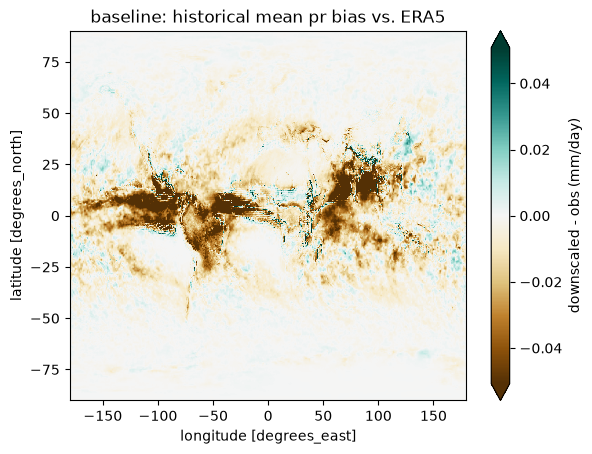

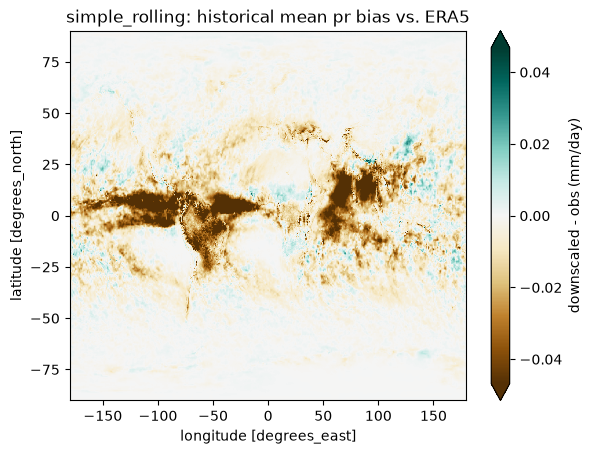

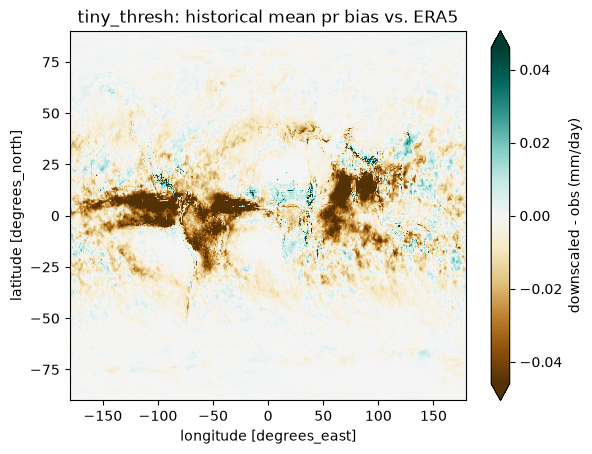

In [21]:
for label, bias in historical_bias.items():
    (bias * 86400).plot(
        cmap=plt.cm.BrBG, center=0, robust=True, cbar_kwargs={"label": "downscaled - obs (mm/day)"}
    )
    plt.title(f"{label}: historical mean pr bias vs. ERA5")
    plt.show()

In [22]:
def summarize_bias(bias: xr.DataArray) -> dict:
    """Units are raw pr (kg/m2/s, ~1e-5 magnitude) -- multiply by 86400 for mm/day."""
    weights = area_weights(bias["lat"])
    return {
        "mean_bias": float(bias.mean(skipna=True)),
        "mean_abs_bias": float(np.abs(bias).mean(skipna=True)),
        "area_weighted_mean_bias": float(bias.weighted(weights).mean(skipna=True)),
        "area_weighted_mean_abs_bias": float(np.abs(bias).weighted(weights).mean(skipna=True)),
    }


historical_bias_summary = pd.DataFrame(
    {label: summarize_bias(bias) for label, bias in historical_bias.items()}
).T
historical_bias_summary

,mean_bias,mean_abs_bias,area_weighted_mean_bias,area_weighted_mean_abs_bias
baseline,-6.090555e-08,8.036884e-08,-8.937678e-08,1.146561e-07
simple_rolling,-5.905531e-08,7.188878e-08,-8.656185e-08,1.019125e-07
tiny_thresh,-5.456947e-08,7.151386e-08,-7.987101e-08,1.012663e-07


## Side-by-side summary

Lower is better everywhere except `historical_bias_vs_obs`, where the sign is informative (positive = branch too high vs. ERA5) and `mean_bias`/`area_weighted_mean_bias` can cancel across sign -- see `mean_abs_bias` for overall magnitude (units are raw `pr`, kg/m2/s -- multiply by 86400 for mm/day). `tiny_thresh` rows will be incomplete until its `ssp245` leaf lands and remain absent from the debiased_coarse table entirely (by design). Remember `baseline`'s numbers reflect a different code version, not just a different disaggregation setting.

In [23]:
all_summary = pd.concat(
    {
        "debiased_coarse_diff_vs_baseline": debiased_coarse_summary,
        "outside_global_plausible_range": global_exceedance_summary,
        "annual_outlier": annual_outlier_summary,
        "trend_distortion_or_sign_flip": trend_summary,
        "historical_bias_vs_obs": historical_bias_summary,
    },
    names=["check", "branch/scenario"],
)
all_summary

max_abs_diff  \
check                            branch/scenario                                           
debiased_coarse_diff_vs_baseline simple_rolling/historical                           0.0   
                                 tiny_thresh/historical                              0.0   
                                 simple_rolling/ssp245                               0.0   
                                 tiny_thresh/ssp245                                  0.0   
outside_global_plausible_range   baseline/historical/downscaled                      NaN   
                                 baseline/ssp245/downscaled                          NaN   
                                 simple_rolling/historical/downscaled                NaN   
                                 simple_rolling/ssp245/downscaled                    NaN   
                                 tiny_thresh/historical/downscaled                   NaN   
                                 tiny_thresh/ssp245/downscaled                       NaN   
                                 baseline/historical/debiased_coarse                 NaN   
                                 baseline/ssp245/debiased_coarse                     NaN   
                                 simple_rolling/historical/debiased_coarse           NaN   
                                 simple_rolling/ssp245/debiased_coarse               NaN   
                                 tiny_thresh/historical/debiased_coarse              NaN   
                                 tiny_thresh/ssp245/debiased_coarse                  NaN   
annual_outlier                   baseline/historical                                 NaN   
                                 baseline/ssp245                                     NaN   
                                 simple_rolling/historical                           NaN   
                                 simple_rolling/ssp245                               NaN   
                                 tiny_thresh/historical                              NaN   
                                 tiny_thresh/ssp245                                  NaN   
trend_distortion_or_sign_flip    baseline/trend_distortion                           NaN   
                                 simple_rolling/trend_distortion                     NaN   
                                 tiny_thresh/trend_distortion                        NaN   
                                 baseline/flipped_sign                               NaN   
                                 simple_rolling/flipped_sign                         NaN   
                                 tiny_thresh/flipped_sign                            NaN   
historical_bias_vs_obs           baseline                                            NaN   
                                 simple_rolling                                      NaN   
                                 tiny_thresh                                         NaN   

                                                                            flagged_pixel_days  \
check                            branch/scenario                                                 
debiased_coarse_diff_vs_baseline simple_rolling/historical                                 NaN   
                                 tiny_thresh/historical                                    NaN   
                                 simple_rolling/ssp245                                     NaN   
                                 tiny_thresh/ssp245                                        NaN   
outside_global_plausible_range   baseline/historical/downscaled                            0.0   
                                 baseline/ssp245/downscaled                                0.0   
                                 simple_rolling/historical/downscaled                      0.0   
                                 simple_rolling/ssp245/downscaled                          0.0   
                                 tiny_thresh/historical/dow

## Other evaluations to consider

Not implemented here — same candidates as the rsds notebook, adapted to `pr`'s edge case. The regional investigation that motivated PR #664 flagged East Africa's dry-season near-zero climatology as `pr`'s equivalent of rsds's polar-night blow-up (`notebooks/QA_QC/spatial_disaggregation/clim-method-eastafrica-pr.ipynb`), so these are most likely to matter in dry regions/seasons rather than uniformly:

- **Temporal-variance ratio vs. ERA5**, globally, especially at low-climatology (dry-season) cells: `simple_rolling` smooths the day-of-year climatology and could dampen real day-to-day variability there, while `tiny_thresh`'s override on specific days could introduce discontinuities.
- **Zonal-mean seasonal-cycle drift**: a cheap sanity check that neither fix accidentally shifts the coarse-scale climatology itself, which disaggregation is only supposed to spatially redistribute.
- **Override/smoothing-magnitude diagnostic**: how often `tiny_thresh`'s override actually triggers vs. how much `simple_rolling`'s rolling mean actually changes the climatology, globally rather than at one edge-case point.